In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

repo_root = Path().resolve().parents[0]  # notebooks/ -> repo root
sys.path.insert(0, str(repo_root))

In [3]:
import pickle as pkl
from src.dataset.dataset import TracesDataset

In [4]:
with open(r"../data/raw/gtea_target.pkl", "rb") as f:
    gtea_target = pkl.load(f)
with open(r"../data/raw/gtea_softmax.pkl", "rb") as f:
    gtea_source = pkl.load(f)
with open(r"../data/processed/gtea_unified.pkl", "rb") as f:
    gtea_unified = pkl.load(f)

In [5]:
gtea_target[0].shape, gtea_source[0].shape

((1643,), (1, 11, 1643))

In [6]:
tds = TracesDataset(gtea_target, gtea_source)

In [7]:
batch = tds[:5]

In [8]:
[x.shape for x in batch[0]]

[torch.Size([1643]),
 torch.Size([1643]),
 torch.Size([1643]),
 torch.Size([1643]),
 torch.Size([943])]

In [9]:
[x.shape for x in batch[1]]

[torch.Size([1643, 11]),
 torch.Size([1643, 11]),
 torch.Size([1643, 11]),
 torch.Size([1643, 11]),
 torch.Size([943, 11])]

In [14]:
from torch.nn.utils.rnn import pad_sequence
from torch.nn.functional import one_hot

pad_value = tds.n_classes

label_batch = one_hot(pad_sequence(batch[0], batch_first=True, padding_value=pad_value), num_classes=max(tds.n_classes, pad_value + 1))

In [15]:
import torch.nn.functional as F

output_constant = pad_sequence(batch[1], batch_first=True, padding_value=0)
output_constant = F.pad(output_constant, (0, label_batch.shape[-1] - output_constant.shape[-1]), value=0.0)
output_constant.shape

torch.Size([5, 1643, 12])

In [14]:
from torch.utils.data import DataLoader
from src.dataset.dataset import collate_traces_batch, collate_traces_batch_probabilistic
from functools import partial

num_channels = 12
collate_one_hot = partial(collate_traces_batch_probabilistic, padding_value=11, final_channels=num_channels, one_hot_labels=True)

dataloader = DataLoader(tds, batch_size=1, shuffle=True, collate_fn=collate_one_hot)

In [15]:
next(iter(dataloader))

(tensor([[[0, 0, 0,  ..., 0, 1, 0],
          [0, 0, 0,  ..., 0, 1, 0],
          [0, 0, 0,  ..., 0, 1, 0],
          ...,
          [0, 0, 0,  ..., 0, 1, 0],
          [0, 0, 0,  ..., 0, 1, 0],
          [0, 0, 0,  ..., 0, 1, 0]]]),
 tensor([[[1.2113e-01, 4.1136e-02, 5.7114e-03,  ..., 3.2710e-03,
           7.9648e-01, 0.0000e+00],
          [1.6115e-01, 4.3697e-02, 5.9891e-03,  ..., 3.4240e-03,
           7.5115e-01, 0.0000e+00],
          [1.1685e-01, 3.2646e-02, 5.9917e-03,  ..., 2.7949e-03,
           8.1477e-01, 0.0000e+00],
          ...,
          [2.4969e-04, 3.8354e-04, 3.7497e-04,  ..., 2.4437e-05,
           9.9836e-01, 0.0000e+00],
          [2.7108e-04, 4.0126e-04, 3.8197e-04,  ..., 2.4226e-05,
           9.9833e-01, 0.0000e+00],
          [2.3764e-04, 3.9270e-04, 3.3228e-04,  ..., 2.2215e-05,
           9.9844e-01, 0.0000e+00]]]))

In [17]:
dk_trace, sk_trace = next(iter(dataloader))
dk_trace = dk_trace.squeeze(0)
sk_trace = sk_trace.squeeze(0)

(<Figure size 1200x150 with 1 Axes>, <Axes: xlabel='Time Step'>)

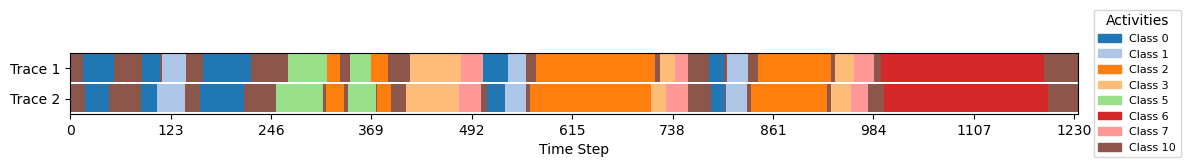

In [43]:
from src.utils.trace_utils import *

visualize_traces_segmentation([sk_trace, dk_trace])

(<Figure size 1200x150 with 1 Axes>, <Axes: xlabel='Time Step'>)

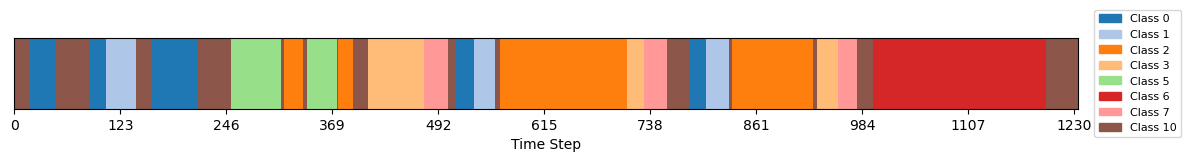

In [40]:
visualize_trace_segmentation(dk_trace)